In [1]:
! pip install torch torchvision torchaudio
! pip install timm
! pip install scikit-learn matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
! pip install kaggle

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image, UnidentifiedImageError
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tuladhar07","key":"7a497c52203d8bec2cb371f1a65d1e15"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/microsoft-catsvsdogs-dataset


In [10]:
import os

def print_tree(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = '│   ' * level + '├── '
        print(f"{indent}{os.path.basename(root)}/")
        sub_indent = '│   ' * (level + 1)
        for f in files:
            print(f"{sub_indent}├── {f}")

# Use your dataset path here
print_tree("/kaggle/input/microsoft-catsvsdogs-dataset")

Streaming output truncated to the last 5000 lines.
│   │   │   ├── 12397.jpg
│   │   │   ├── 11444.jpg
│   │   │   ├── 4997.jpg
│   │   │   ├── 11760.jpg
│   │   │   ├── 8409.jpg
│   │   │   ├── 5224.jpg
│   │   │   ├── 4886.jpg
│   │   │   ├── 7164.jpg
│   │   │   ├── 1045.jpg
│   │   │   ├── 7361.jpg
│   │   │   ├── 7148.jpg
│   │   │   ├── 11785.jpg
│   │   │   ├── 1374.jpg
│   │   │   ├── 2927.jpg
│   │   │   ├── 7913.jpg
│   │   │   ├── 4065.jpg
│   │   │   ├── 8618.jpg
│   │   │   ├── 9598.jpg
│   │   │   ├── 4110.jpg
│   │   │   ├── 4585.jpg
│   │   │   ├── 7536.jpg
│   │   │   ├── 5521.jpg
│   │   │   ├── 9899.jpg
│   │   │   ├── 1828.jpg
│   │   │   ├── 10481.jpg
│   │   │   ├── 7879.jpg
│   │   │   ├── 769.jpg
│   │   │   ├── 6026.jpg
│   │   │   ├── 9130.jpg
│   │   │   ├── 2853.jpg
│   │   │   ├── 7817.jpg
│   │   │   ├── 1881.jpg
│   │   │   ├── 8278.jpg
│   │   │   ├── 11839.jpg
│   │   │   ├── 8569.jpg
│   │   │   ├── 2289.jpg
│   │   │   ├── 1121.jpg
│   │   │   ├── 800

In [14]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset

# Unzip the data quietly
!unzip -q microsoft-catsvsdogs-dataset.zip

# Verify the structure (should show a 'PetImages' folder)
!ls

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
 99% 782M/788M [00:14<00:00, 38.1MB/s]
100% 788M/788M [00:14<00:00, 56.2MB/s]
 kaggle.json			   'MSR-LA - 3467.docx'  'readme[1].txt'
 microsoft-catsvsdogs-dataset.zip   PetImages		  sample_data


In [15]:
SOURCE_DIR = 'PetImages'
OUTPUT_DIR = 'dataset_split'
VAL_SPLIT = 0.2 # 20% of data for validation

print("--- Starting Data Cleaning and Splitting ---")

# Remove the output directory if it exists to start fresh
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

# --- 1. Clean Corrupted Images ---
corrupted_count = 0
for pet_class in ['Cat', 'Dog']:
    class_dir = os.path.join(SOURCE_DIR, pet_class)
    if not os.path.isdir(class_dir):
        print(f"Error: Directory not found at '{class_dir}'")
        continue

    print(f"Scanning '{pet_class}' images...")
    for filename in os.listdir(class_dir):
        filepath = os.path.join(class_dir, filename)
        try:
            with Image.open(filepath) as img:
                img.verify() # Checks for file integrity
            # Also remove zero-byte files
            if os.path.getsize(filepath) == 0:
              raise ValueError("Zero-byte file")
        except (IOError, UnidentifiedImageError, ValueError) as e:
            print(f"Removing corrupted file: {filepath} ({e})")
            os.remove(filepath)
            corrupted_count += 1
print(f"\nCleaning complete. Removed {corrupted_count} corrupted files.")

--- Starting Data Cleaning and Splitting ---
Scanning 'Cat' images...
Removing corrupted file: PetImages/Cat/Thumbs.db (cannot identify image file 'PetImages/Cat/Thumbs.db')
Removing corrupted file: PetImages/Cat/666.jpg (cannot identify image file 'PetImages/Cat/666.jpg')
Scanning 'Dog' images...
Removing corrupted file: PetImages/Dog/Thumbs.db (cannot identify image file 'PetImages/Dog/Thumbs.db')


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Removing corrupted file: PetImages/Dog/11702.jpg (cannot identify image file 'PetImages/Dog/11702.jpg')

Cleaning complete. Removed 4 corrupted files.


In [16]:
# --- 2. Split Data into Train/Val and Create New Structure ---
print("\n--- Creating train/validation split ---")
train_dir = os.path.join(OUTPUT_DIR, 'train')
val_dir = os.path.join(OUTPUT_DIR, 'val')
os.makedirs(os.path.join(train_dir, 'cat'), exist_ok=True)
os.makedirs(os.path.join(train_dir, 'dog'), exist_ok=True)
os.makedirs(os.path.join(val_dir, 'cat'), exist_ok=True)
os.makedirs(os.path.join(val_dir, 'dog'), exist_ok=True)

def split_and_copy(source_class_dir, train_dest, val_dest):
    files = [os.path.join(source_class_dir, f) for f in os.listdir(source_class_dir)]
    train_files, val_files = train_test_split(files, test_size=VAL_SPLIT, random_state=42)

    for f in train_files:
        shutil.copy(f, train_dest)
    for f in val_files:
        shutil.copy(f, val_dest)
    print(f"Split {os.path.basename(source_class_dir)}: {len(train_files)} train, {len(val_files)} val")

split_and_copy(os.path.join(SOURCE_DIR, 'Cat'), os.path.join(train_dir, 'cat'), os.path.join(val_dir, 'cat'))
split_and_copy(os.path.join(SOURCE_DIR, 'Dog'), os.path.join(train_dir, 'dog'), os.path.join(val_dir, 'dog'))

print(f"\nData successfully cleaned and organized in '{OUTPUT_DIR}' directory.")


--- Creating train/validation split ---
Split Cat: 9999 train, 2500 val
Split Dog: 9999 train, 2500 val

Data successfully cleaned and organized in 'dataset_split' directory.


In [17]:
# Cell 4: Configuration and DataLoaders
CONFIG = {
    "batch_size": 32,
    "img_size": 224,
    "num_classes": 2, # Cats vs Dogs
    "learning_rate": 3e-4,
    "num_epochs": 5,
    "model_name": 'vit_tiny_patch16_224',
    "dataset_path": 'dataset_split/' # <<< Use our newly created folder
}

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Define transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(CONFIG["img_size"]),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.CenterCrop(CONFIG["img_size"]),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load datasets using ImageFolder
train_dataset = datasets.ImageFolder(root=os.path.join(CONFIG["dataset_path"], 'train'), transform=train_transform)
val_dataset = datasets.ImageFolder(root=os.path.join(CONFIG["dataset_path"], 'val'), transform=val_transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

print(f"\nFound {len(train_dataset)} training images and {len(val_dataset)} validation images.")
print(f"Classes: {train_dataset.classes}")

Using device: cuda

Found 19998 training images and 5000 validation images.
Classes: ['cat', 'dog']


In [18]:
# Cell 5: Define the Model
model = timm.create_model(
    CONFIG["model_name"],
    pretrained=True,
    num_classes=CONFIG["num_classes"] # This modifies the final MLP Head for our task
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

In [19]:
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.9)

In [20]:
# Cell 6: Training and Validation Loop
print("Starting training...")
for epoch in range(CONFIG["num_epochs"]):
    model.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{CONFIG["num_epochs"]}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

    epoch_loss = running_loss / len(train_dataset)

    model.eval()
    val_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_val_loss = val_loss / len(val_dataset)
    accuracy = accuracy_score(all_labels, all_preds)

    print(f"\n--- Epoch {epoch+1}/{CONFIG['num_epochs']} Summary ---")
    print(f"Train Loss: {epoch_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Accuracy: {accuracy:.4f}\n")
    scheduler.step()

print("Training finished!")

Starting training...
Epoch [1/5], Step [100/625], Loss: 0.1628
Epoch [1/5], Step [200/625], Loss: 0.0976
Epoch [1/5], Step [300/625], Loss: 0.2325
Epoch [1/5], Step [400/625], Loss: 0.2069
Epoch [1/5], Step [500/625], Loss: 0.3105
Epoch [1/5], Step [600/625], Loss: 0.3352

--- Epoch 1/5 Summary ---
Train Loss: 0.2276 | Val Loss: 0.1532 | Val Accuracy: 0.9334

Epoch [2/5], Step [100/625], Loss: 0.1898
Epoch [2/5], Step [200/625], Loss: 0.1574
Epoch [2/5], Step [300/625], Loss: 0.0753


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [2/5], Step [400/625], Loss: 0.1283
Epoch [2/5], Step [500/625], Loss: 0.1630
Epoch [2/5], Step [600/625], Loss: 0.2047

--- Epoch 2/5 Summary ---
Train Loss: 0.1955 | Val Loss: 0.1688 | Val Accuracy: 0.9324

Epoch [3/5], Step [100/625], Loss: 0.0619


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [3/5], Step [200/625], Loss: 0.3546
Epoch [3/5], Step [300/625], Loss: 0.2570
Epoch [3/5], Step [400/625], Loss: 0.1258
Epoch [3/5], Step [500/625], Loss: 0.1205
Epoch [3/5], Step [600/625], Loss: 0.0636

--- Epoch 3/5 Summary ---
Train Loss: 0.1721 | Val Loss: 0.2083 | Val Accuracy: 0.9176

Epoch [4/5], Step [100/625], Loss: 0.1293


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [4/5], Step [200/625], Loss: 0.1684
Epoch [4/5], Step [300/625], Loss: 0.1692
Epoch [4/5], Step [400/625], Loss: 0.2748
Epoch [4/5], Step [500/625], Loss: 0.0828
Epoch [4/5], Step [600/625], Loss: 0.0660

--- Epoch 4/5 Summary ---
Train Loss: 0.1718 | Val Loss: 0.1363 | Val Accuracy: 0.9408

Epoch [5/5], Step [100/625], Loss: 0.1082
Epoch [5/5], Step [200/625], Loss: 0.1464
Epoch [5/5], Step [300/625], Loss: 0.1931
Epoch [5/5], Step [400/625], Loss: 0.1765
Epoch [5/5], Step [500/625], Loss: 0.2178


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [5/5], Step [600/625], Loss: 0.2074

--- Epoch 5/5 Summary ---
Train Loss: 0.1556 | Val Loss: 0.1611 | Val Accuracy: 0.9356

Training finished!


--- Final Model Evaluation ---
Final Validation Accuracy: 0.9356


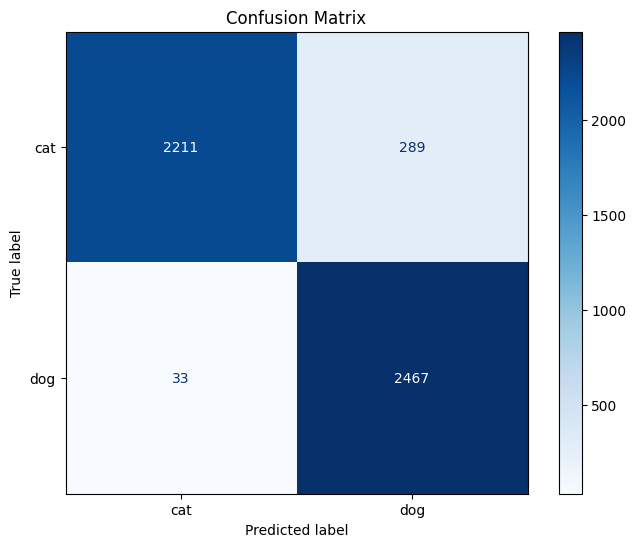


Visualizing some random predictions from the validation set...


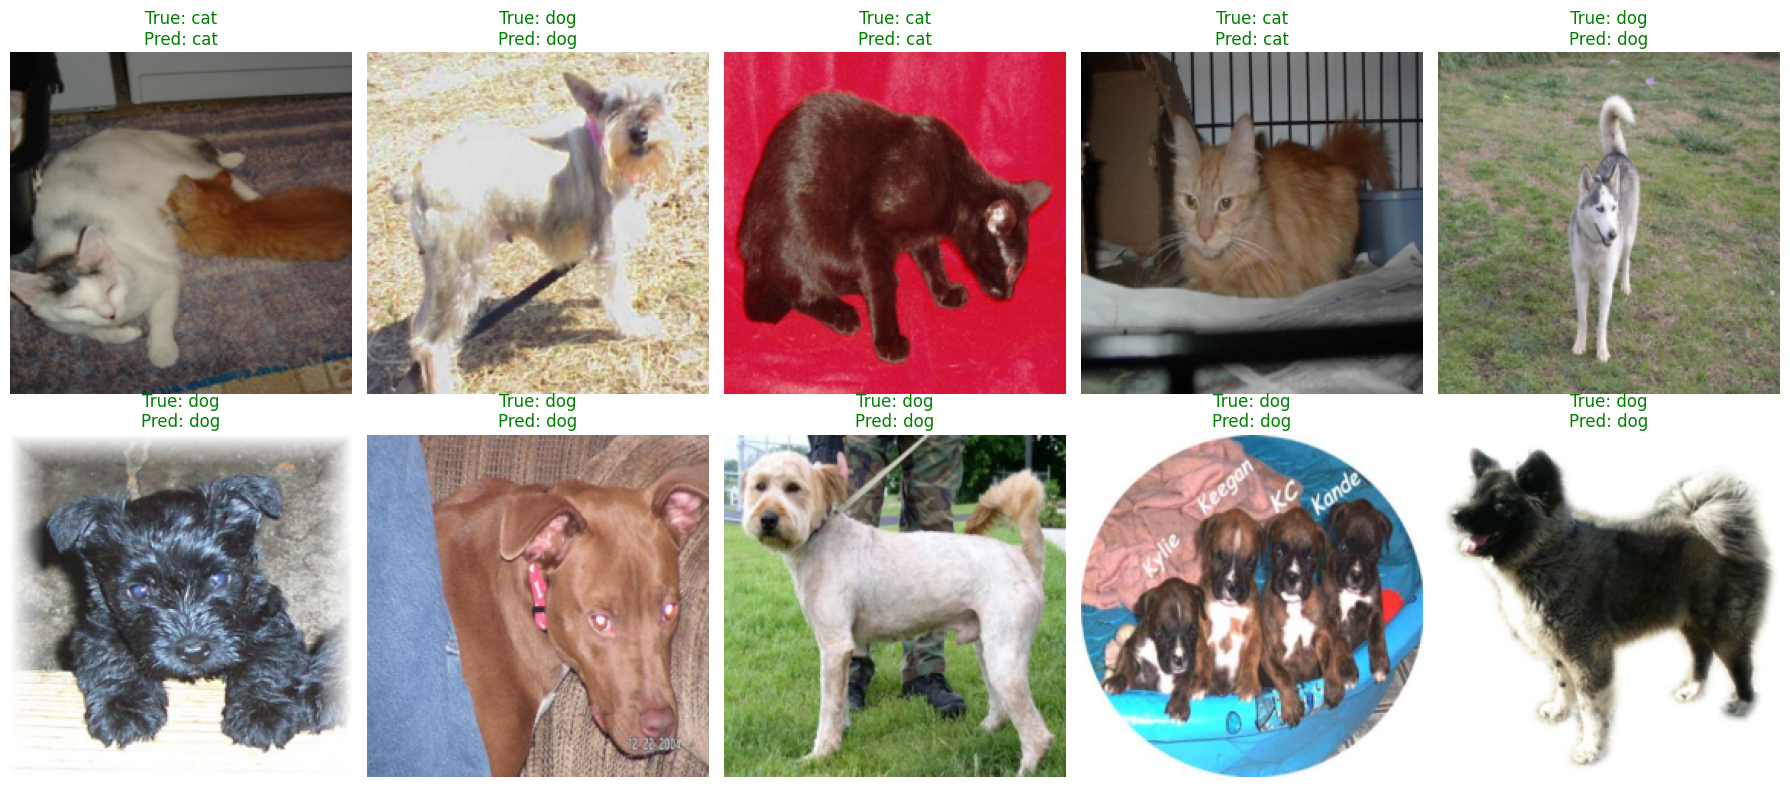

In [21]:
# Cell 7: Final Evaluation and Visualization
print("--- Final Model Evaluation ---")
final_accuracy = accuracy_score(all_labels, all_preds)
print(f"Final Validation Accuracy: {final_accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Visualize predictions
def visualize_predictions(dataset, num_images=10):
    model.eval()
    plt.figure(figsize=(18, 8))
    indices = np.random.choice(len(dataset), num_images, replace=False)

    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        image_for_display = image.permute(1, 2, 0).numpy()
        mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
        image_for_display = std * image_for_display + mean
        image_for_display = np.clip(image_for_display, 0, 1)

        with torch.no_grad():
            output = model(image.unsqueeze(0).to(device))
            _, pred_idx = torch.max(output, 1)

        pred_class, true_class = dataset.classes[pred_idx.item()], dataset.classes[label]

        plt.subplot(2, 5, i + 1)
        plt.imshow(image_for_display)
        plt.title(f"True: {true_class}\nPred: {pred_class}", color=("green" if pred_class == true_class else "red"))
        plt.axis('off')

    plt.tight_layout()
    plt.show()

print("\nVisualizing some random predictions from the validation set...")
visualize_predictions(val_dataset)

Please upload a test image of a cat or a dog.


Saving cat.jpeg to cat.jpeg

Processing 'cat.jpeg'...


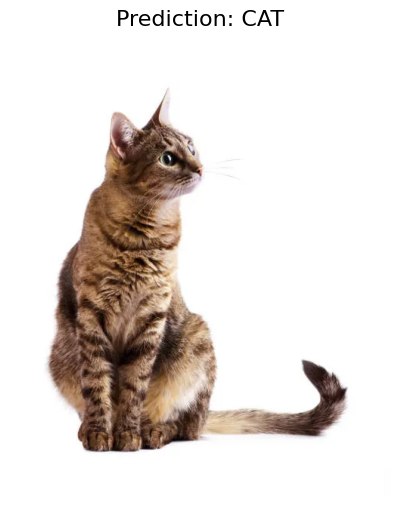


--- Prediction Confidence ---
Cat: 99.43%
Dog: 0.57%


In [24]:
# Cell 8: Test the model with a single custom image

from google.colab import files
from PIL import Image

def predict_single_image(model, image_path, transform, class_names, device):
    """
    Predicts the class of a single image.

    Args:
        model: The trained PyTorch model.
        image_path: Path to the image file.
        transform: The transformation to apply to the image.
        class_names: A list of class names.
        device: The device to run inference on ('cuda' or 'cpu').

    Returns:
        A tuple containing the predicted class name and the prediction probabilities.
    """
    # 1. Load and preprocess the image
    try:
        image = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"Error opening image: {e}")
        return None, None

    # Apply the same transformations as the validation set
    image_tensor = transform(image)

    # 2. Add a batch dimension
    # The model expects a batch of images (N, C, H, W), so we add N=1
    image_tensor = image_tensor.unsqueeze(0)

    # 3. Move the tensor to the correct device
    image_tensor = image_tensor.to(device)

    # 4. Set the model to evaluation mode and get predictions
    model.eval()
    with torch.no_grad():
        output = model(image_tensor)

    # 5. Post-process the output
    # Apply softmax to get probabilities
    probabilities = torch.nn.functional.softmax(output, dim=1)

    # Get the top prediction
    top_prob, top_idx = torch.max(probabilities, 1)
    predicted_idx = top_idx.item()
    predicted_class = class_names[predicted_idx]

    # Create a dictionary of class probabilities
    probs_dict = {class_names[i]: probabilities[0][i].item() for i in range(len(class_names))}

    return predicted_class, probs_dict

# --- Main execution ---
print("Please upload a test image of a cat or a dog.")
uploaded = files.upload()

# Check if a file was uploaded
if len(uploaded.keys()) == 0:
    print("No file uploaded. Please run the cell again.")
else:
    # Get the filename of the uploaded file
    uploaded_filename = next(iter(uploaded))
    print(f"\nProcessing '{uploaded_filename}'...")

    # Predict the class of the uploaded image
    # We use `val_transform` because we are not augmenting a test image
    predicted_class, probs = predict_single_image(
        model=model,
        image_path=uploaded_filename,
        transform=val_transform,
        class_names=train_dataset.classes,
        device=device
    )

    # Display the results
    if predicted_class:
        # Display the image
        display_image = Image.open(uploaded_filename)
        plt.figure(figsize=(6,6))
        plt.imshow(display_image)
        plt.title(f"Prediction: {predicted_class.upper()}", fontsize=16)
        plt.axis('off')
        plt.show()

        print("\n--- Prediction Confidence ---")
        for cls, prob in probs.items():
            print(f"{cls.capitalize()}: {prob*100:.2f}%")